# Marketing Campaign Analysis & Response Prediction (Python + ML)
## 	Dataset Used: 
    Marketing Campaign Dataset – Customer Personality Analysis
    Source: Kaggle
    Contains: customer demographics, income, spending, campaign responses
### This project analyzes customer behavior using a marketing campaign dataset.
### Machine learning models were used to predict whether a customer will respond to a campaign.
### Random Forest achieved the best performance and feature importance helped identify key influencing factors.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,r2_score
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.naive_bayes import GaussianNB

In [2]:
df = pd.read_csv("marketing_campaign.csv", sep="\t")
df.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,...,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,...,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,...,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,...,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,...,20,1,0,0,0,0,0,3,11,0


In [3]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [4]:
# remove duplicates
df = df.drop_duplicates()

# convert date
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

# create age column
df['Age'] = 2024 - df['Year_Birth']

# total spending
df['Total_Spending'] = (
    df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] +
    df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
)

# handle missing income
df['Income'] = df['Income'].fillna(df['Income'].median())

# drop unused
df = df.drop(['ID','Year_Birth'], axis=1)

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Education            2240 non-null   object        
 1   Marital_Status       2240 non-null   object        
 2   Income               2240 non-null   float64       
 3   Kidhome              2240 non-null   int64         
 4   Teenhome             2240 non-null   int64         
 5   Dt_Customer          2240 non-null   datetime64[ns]
 6   Recency              2240 non-null   int64         
 7   MntWines             2240 non-null   int64         
 8   MntFruits            2240 non-null   int64         
 9   MntMeatProducts      2240 non-null   int64         
 10  MntFishProducts      2240 non-null   int64         
 11  MntSweetProducts     2240 non-null   int64         
 12  MntGoldProds         2240 non-null   int64         
 13  NumDealsPurchases    2240 non-nul

,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spending
count,2240.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000,2240.000000,2240.000000
mean,52237.975446,0.444196,0.506250,2013-07-10 10:01:42.857142784,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,...,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107,55.194196,605.798214
min,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,28.000000,5.000000
25%,35538.750000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,47.000000,68.750000
50%,51381.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,54.000000,396.000000
75%,68289.750000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,65.000000,1045.500000
max,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,131.000000,2525.000000
std,25037.955891,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,...,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274,11.984069,602.249288


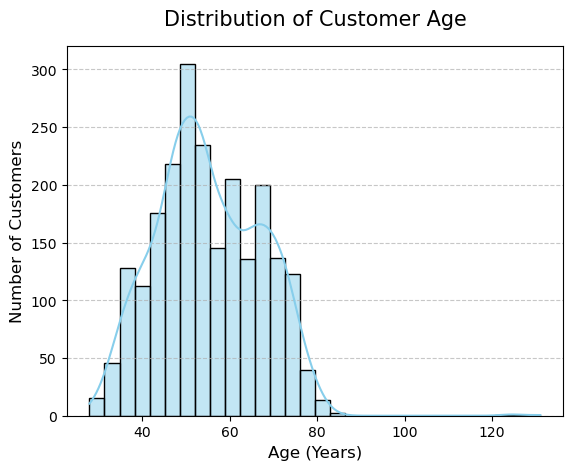

In [6]:
sns.histplot(df['Age'], bins=30, kde=True, color='skyblue', edgecolor='black')

plt.title('Distribution of Customer Age', fontsize=15, pad=15)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

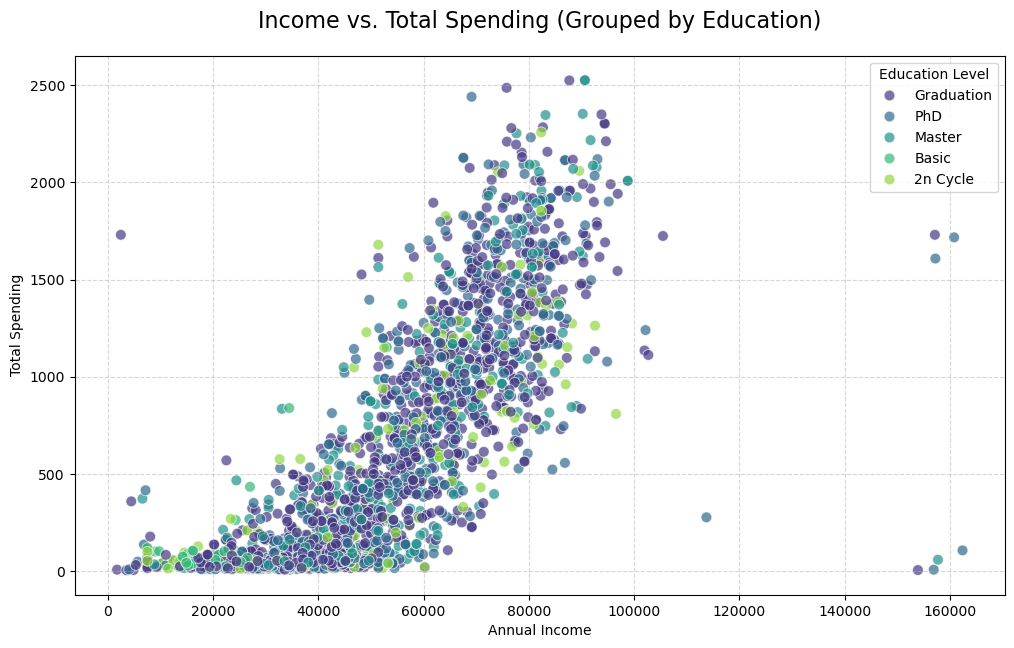

In [7]:
df_filtered = df[df['Income'] < 200000]

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_filtered,x='Income',y='Total_Spending',hue='Education',palette='viridis', 
alpha=0.7,s=60)

plt.title('Income vs. Total Spending (Grouped by Education)', fontsize=16, pad=20)
plt.xlabel('Annual Income')
plt.ylabel('Total Spending')
plt.legend(title='Education Level')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

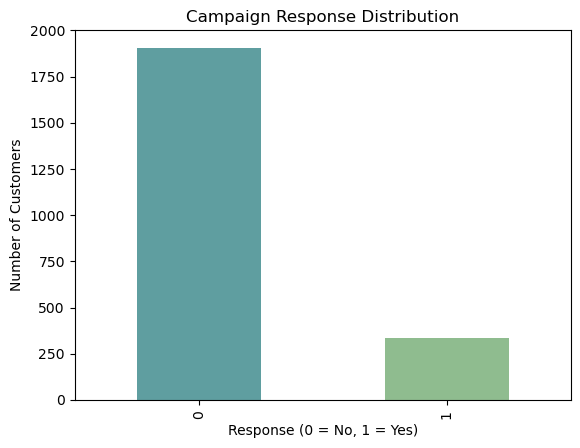

In [8]:
df['Response'].value_counts().plot(kind='bar',color=['cadetblue', 'darkseagreen'])
plt.title('Campaign Response Distribution')
plt.xlabel('Response (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.show()

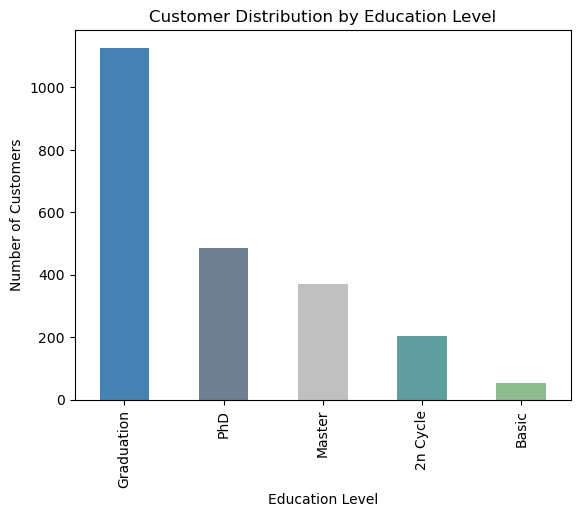

In [9]:
df['Education'].value_counts().plot(kind='bar',color=['steelblue', 'slategrey', 'silver', 'cadetblue', 'darkseagreen'])
plt.title("Customer Distribution by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Number of Customers")
plt.show()

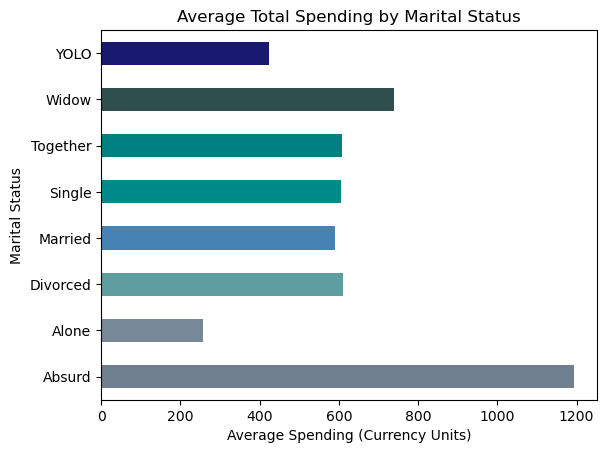

In [10]:
df.groupby('Marital_Status')['Total_Spending'].mean().plot(kind='barh',color= ['slategrey', 'lightslategray', 'cadetblue', 'steelblue', 'darkcyan', 'teal', 'darkslategrey', 'midnightblue'])
plt.title('Average Total Spending by Marital Status')
plt.xlabel('Average Spending (Currency Units)')
plt.ylabel('Marital Status')
plt.show()

Objective 1 — Predict Campaign Response

Business Question: Which customers will accept marketing campaign?
Target → Response
Problem → Classification

We will compare:
	•	Logistic Regression
	•	Decision Tree
	•	Random Forest

In [11]:
X = df[['Income','Age','Recency','Total_Spending']]
y = df['Response']


X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

Model 1 — Logistic Regression

In [12]:
model1 = LogisticRegression()
model1.fit(X_train,y_train)

pred1 = model1.predict(X_test)

acc1 = accuracy_score(y_test,pred1)
print("Logistic Accuracy:",acc1)
cr1 = classification_report(y_test,pred1)
print("Confusion Matrix\n",cr1)

Logistic Accuracy: 0.8638392857142857
Confusion Matrix
               precision    recall  f1-score   support

           0       0.88      0.98      0.93       394
           1       0.18      0.04      0.06        54

    accuracy                           0.86       448
   macro avg       0.53      0.51      0.49       448
weighted avg       0.80      0.86      0.82       448



Model 2 — Decision Tree

In [13]:
model2 = DecisionTreeClassifier(max_depth=4)
model2.fit(X_train,y_train)

pred2 = model2.predict(X_test)

acc2 = accuracy_score(y_test,pred2)
print("Decision Tree Accuracy:",acc2)
cr2 = classification_report(y_test,pred2)
print("Confusion Matrix\n",cr2)

Decision Tree Accuracy: 0.8616071428571429
Confusion Matrix
               precision    recall  f1-score   support

           0       0.88      0.97      0.92       394
           1       0.25      0.07      0.11        54

    accuracy                           0.86       448
   macro avg       0.57      0.52      0.52       448
weighted avg       0.81      0.86      0.83       448



Model 3 - Random Forest

In [14]:
model3 = RandomForestClassifier(n_estimators=100)
model3.fit(X_train,y_train)

pred3 = model3.predict(X_test)

acc3 = accuracy_score(y_test,pred3)
print("Random Forest Accuracy:",acc3)
cr3 = classification_report(y_test,pred3)
print("Confusion Matrix\n",cr3)

Random Forest Accuracy: 0.8549107142857143
Confusion Matrix
               precision    recall  f1-score   support

           0       0.89      0.95      0.92       394
           1       0.32      0.19      0.24        54

    accuracy                           0.85       448
   macro avg       0.61      0.57      0.58       448
weighted avg       0.83      0.85      0.84       448



COMPARISION

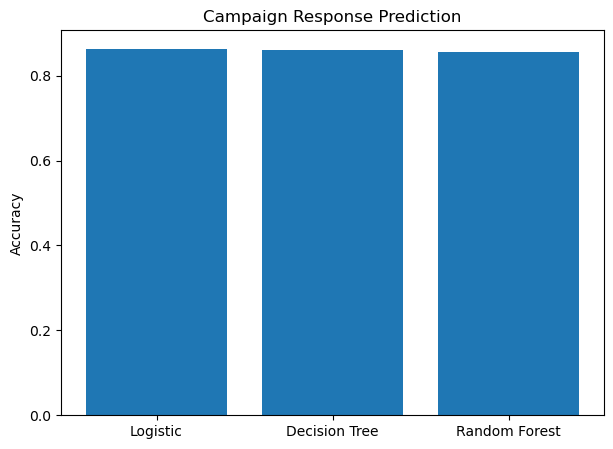

In [15]:
models = ['Logistic','Decision Tree','Random Forest']
scores = [acc1,acc2,acc3]

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.bar(models,scores)

plt.title("Campaign Response Prediction")
plt.ylabel("Accuracy")

plt.show()

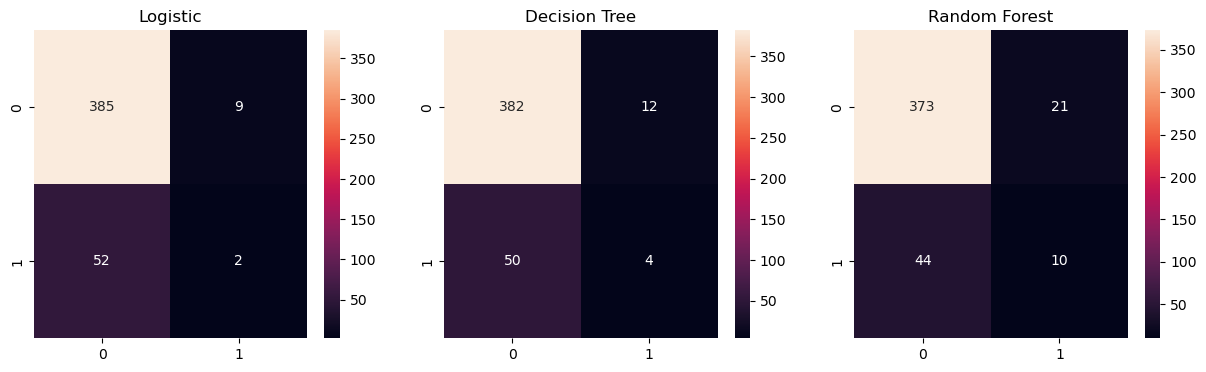

In [16]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.heatmap(confusion_matrix(y_test,pred1),annot=True,fmt='d')
plt.title("Logistic")

plt.subplot(1,3,2)
sns.heatmap(confusion_matrix(y_test,pred2),annot=True,fmt='d')
plt.title("Decision Tree")

plt.subplot(1,3,3)
sns.heatmap(confusion_matrix(y_test,pred3),annot=True,fmt='d')
plt.title("Random Forest")

plt.show()

Since Random forest got the best accuracy then the important features contributing

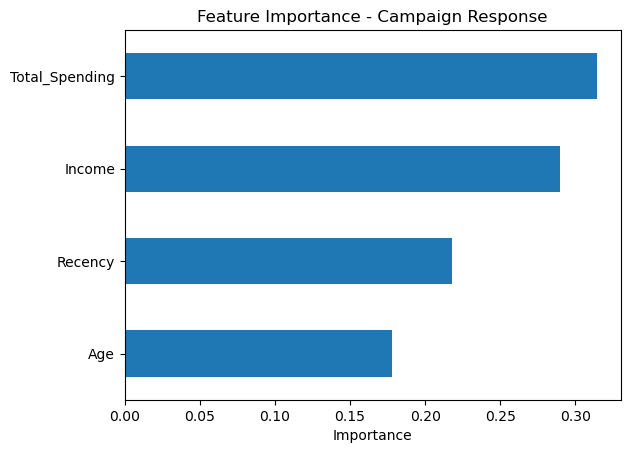

In [17]:
importance = model3.feature_importances_

feat_imp = pd.Series(importance, index=X.columns)

feat_imp.sort_values().plot(kind='barh')

plt.title("Feature Importance - Campaign Response")
plt.xlabel("Importance")

plt.show()

Objective 2 — Predict Customer Spending Cluster

Business Question: Can we classify customers into Low / Medium / High spenders?
Target → Customer_Cluster
Problem → Classification

We compare:
	•	Decision Tree
	•	Random Forest

In [18]:
df['Customer_Cluster'] = pd.cut(
    df['Total_Spending'],
    bins=[0,500,1500,5000],
    labels=['Low','Medium','High']
)

In [19]:
X = df[['Income','Age','Recency']]
y = df['Customer_Cluster']
X_train,X_test,y_train,y_test = train_test_split( X,y,test_size=0.2)

Model 1 - Decision Tree

In [20]:
model4 = DecisionTreeClassifier(max_depth=3)
model4.fit(X_train,y_train)

pred4 = model4.predict(X_test)
acc4 = accuracy_score(y_test,pred4)
print("Decision Tree Accuracy:",acc4)

cr4 = classification_report(y_test,pred4)
print("Confusion Matrix\n",cr4)

Decision Tree Accuracy: 0.7879464285714286
Confusion Matrix
               precision    recall  f1-score   support

        High       0.64      0.20      0.31        45
         Low       0.90      0.88      0.89       251
      Medium       0.65      0.81      0.72       152

    accuracy                           0.79       448
   macro avg       0.73      0.63      0.64       448
weighted avg       0.79      0.79      0.77       448



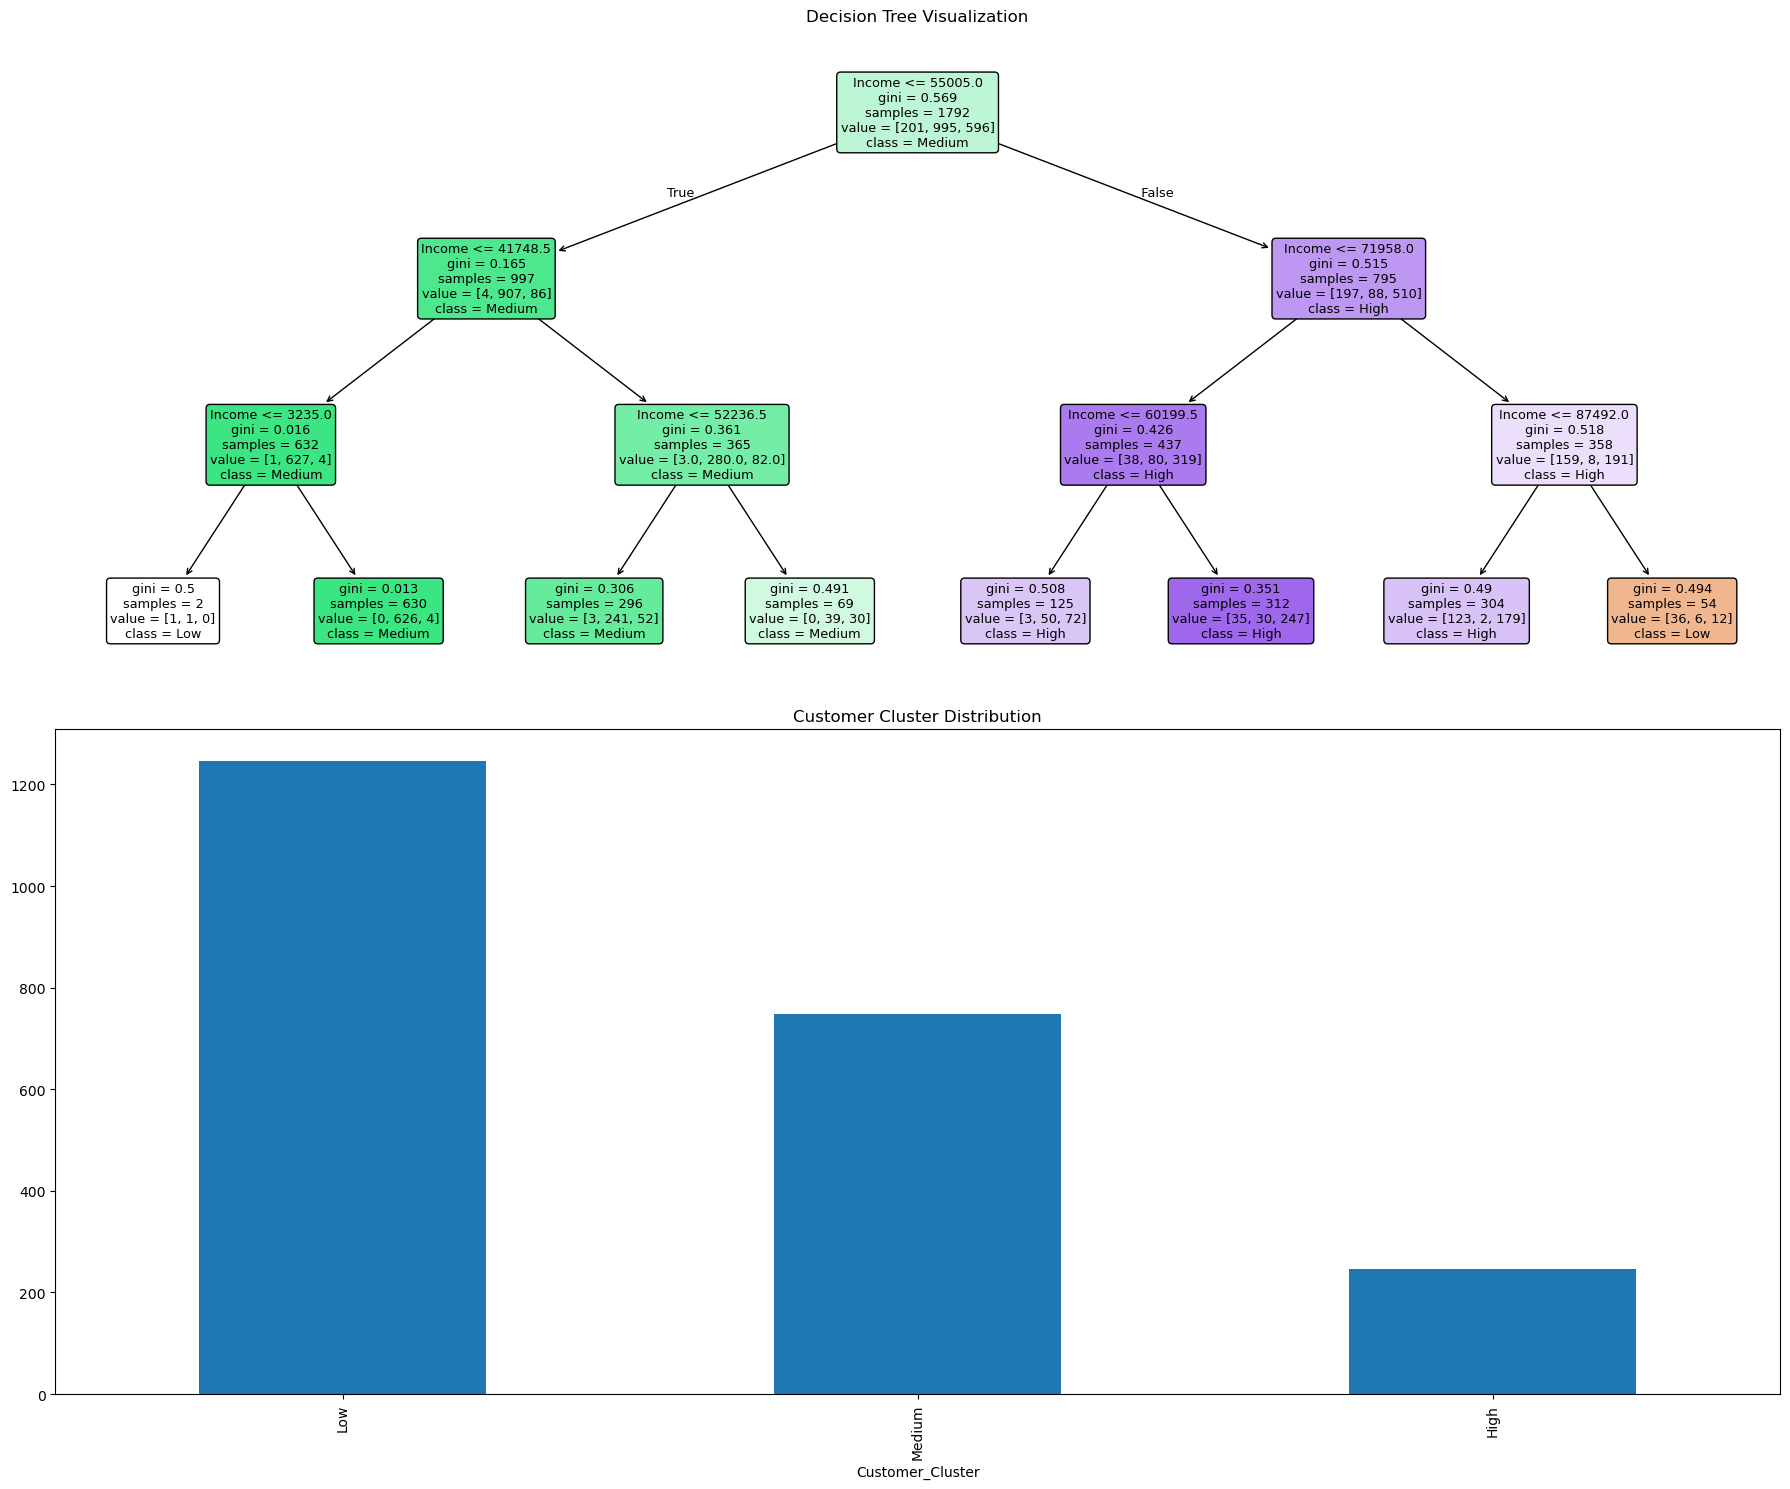

In [21]:
plt.figure(figsize=(18,15))

plt.subplot(2, 1, 1) 
plot_tree(
    model4,
    feature_names=X.columns,
    class_names=['Low','Medium','High'],
    filled=True,
    rounded=True
)
plt.title("Decision Tree Visualization")

# --- Plot 2: Bar Chart (Bottom Row) ---
plt.subplot(2, 1, 2)
df['Customer_Cluster'].value_counts().plot(kind='bar')
plt.title("Customer Cluster Distribution")

plt.tight_layout() # Adds space so the tree doesn't touch the bar chart
plt.show()

Model 2 - Random Forest

In [22]:

model5 = RandomForestClassifier(n_estimators=100)
model5.fit(X_train,y_train)

pred5 = model5.predict(X_test)
acc5 = accuracy_score(y_test,pred5)
print("Random Forest Accuracy:",acc5)
cr5 = classification_report(y_test,pred5)
print("Confusion Matrix\n",cr5)

Random Forest Accuracy: 0.7946428571428571
Confusion Matrix
               precision    recall  f1-score   support

        High       0.59      0.38      0.46        45
         Low       0.90      0.89      0.90       251
      Medium       0.67      0.76      0.72       152

    accuracy                           0.79       448
   macro avg       0.72      0.68      0.69       448
weighted avg       0.79      0.79      0.79       448



COMPARE

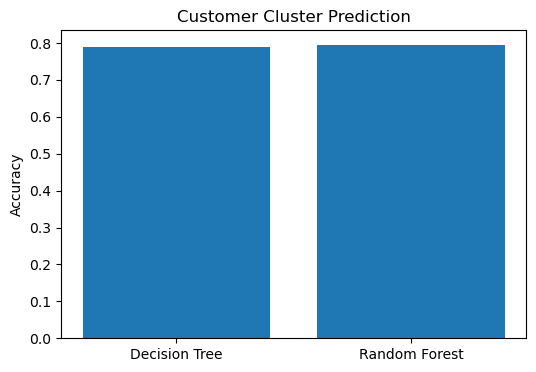

In [23]:
models = ['Decision Tree','Random Forest']
scores = [acc4,acc5]

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(models,scores)

plt.title("Customer Cluster Prediction")
plt.ylabel("Accuracy")

plt.show()

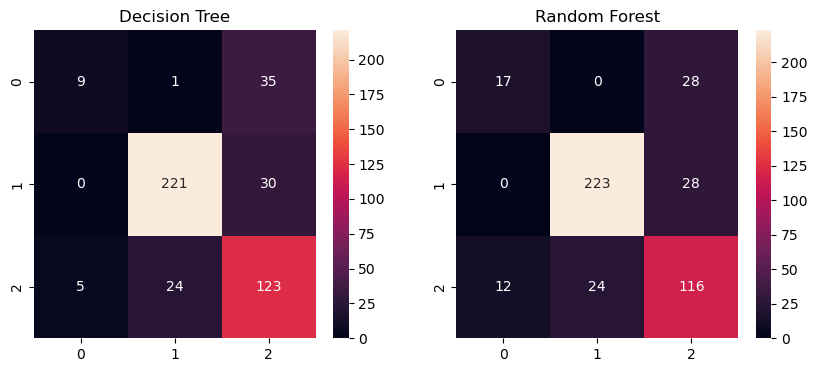

In [24]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(confusion_matrix(y_test,pred4),annot=True,fmt='d')
plt.title("Decision Tree")

plt.subplot(1,2,2)
sns.heatmap(confusion_matrix(y_test,pred5),annot=True,fmt='d')
plt.title("Random Forest")

plt.show()

 Objective 3 — Predict High Value Customers

Business Question: Which customers are high spenders?
Target → High_Value
Problem → Classification

We compare:
	•	Logistic Regression
	•	Decision Tree
	•	Random Forest

In [25]:
df['High_Value'] = (df['Total_Spending'] > 1000).astype(int)

In [26]:
X = df[['Income','Age','Recency']]
y = df['High_Value']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [27]:
model = GaussianNB()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)
acc= accuracy_score(y_test,y_pred)

print("Accuracy:",acc)
cr = classification_report(y_test,y_pred)
print("Confusion Matrix\n",cr)

Accuracy: 0.8727678571428571
Confusion Matrix
               precision    recall  f1-score   support

           0       0.91      0.92      0.92       337
           1       0.75      0.73      0.74       111

    accuracy                           0.87       448
   macro avg       0.83      0.82      0.83       448
weighted avg       0.87      0.87      0.87       448



Model 1 - Logistic Regression

In [28]:
model6 = LogisticRegression()
model6.fit(X_train,y_train)

pred6 = model6.predict(X_test)
acc6 = accuracy_score(y_test,pred6)
print("Logistic Accuracy:",acc6)

cr6 = classification_report(y_test,pred6)
print("Confusion Matrix\n",cr6)

Logistic Accuracy: 0.8727678571428571
Confusion Matrix
               precision    recall  f1-score   support

           0       0.90      0.94      0.92       337
           1       0.78      0.68      0.72       111

    accuracy                           0.87       448
   macro avg       0.84      0.81      0.82       448
weighted avg       0.87      0.87      0.87       448



Model 2 - Decision Tree

In [29]:

model7 = DecisionTreeClassifier(max_depth=4)
model7.fit(X_train,y_train)

pred7 = model7.predict(X_test)

acc7 = accuracy_score(y_test,pred7)
print("Decision Tree Accuracy:",acc7)

cr7 = classification_report(y_test,pred7)
print("Confusion Matrix\n",cr7)

Decision Tree Accuracy: 0.875
Confusion Matrix
               precision    recall  f1-score   support

           0       0.89      0.95      0.92       337
           1       0.80      0.66      0.72       111

    accuracy                           0.88       448
   macro avg       0.85      0.80      0.82       448
weighted avg       0.87      0.88      0.87       448



Model 3 - Random Forest

In [30]:
model8 = RandomForestClassifier(n_estimators=100)
model8.fit(X_train,y_train)

pred8 = model8.predict(X_test)

acc8 = accuracy_score(y_test,pred8)
print("Random Forest Accuracy:",acc8)

cr8 = classification_report(y_test,pred8)
print("Confusion Matrix\n",cr8)

Random Forest Accuracy: 0.8660714285714286
Confusion Matrix
               precision    recall  f1-score   support

           0       0.90      0.92      0.91       337
           1       0.75      0.69      0.72       111

    accuracy                           0.87       448
   macro avg       0.82      0.81      0.82       448
weighted avg       0.86      0.87      0.86       448



COMPARE

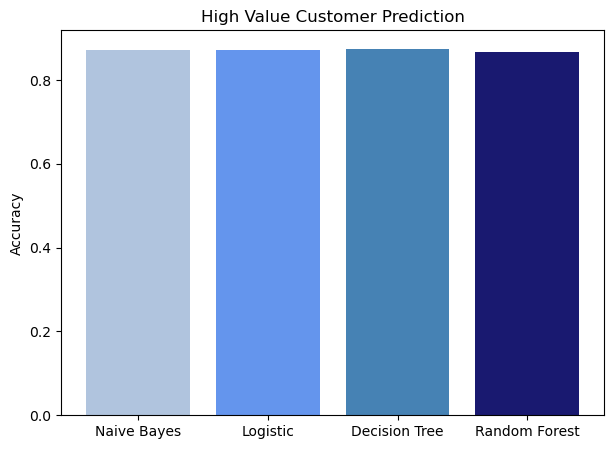

In [31]:
models = ['Naive Bayes','Logistic','Decision Tree','Random Forest']
scores = [acc,acc6,acc7,acc8]

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.bar(models,scores,color=['lightsteelblue', 'cornflowerblue', 'steelblue', 'midnightblue'])

plt.title("High Value Customer Prediction")
plt.ylabel("Accuracy")

plt.show()

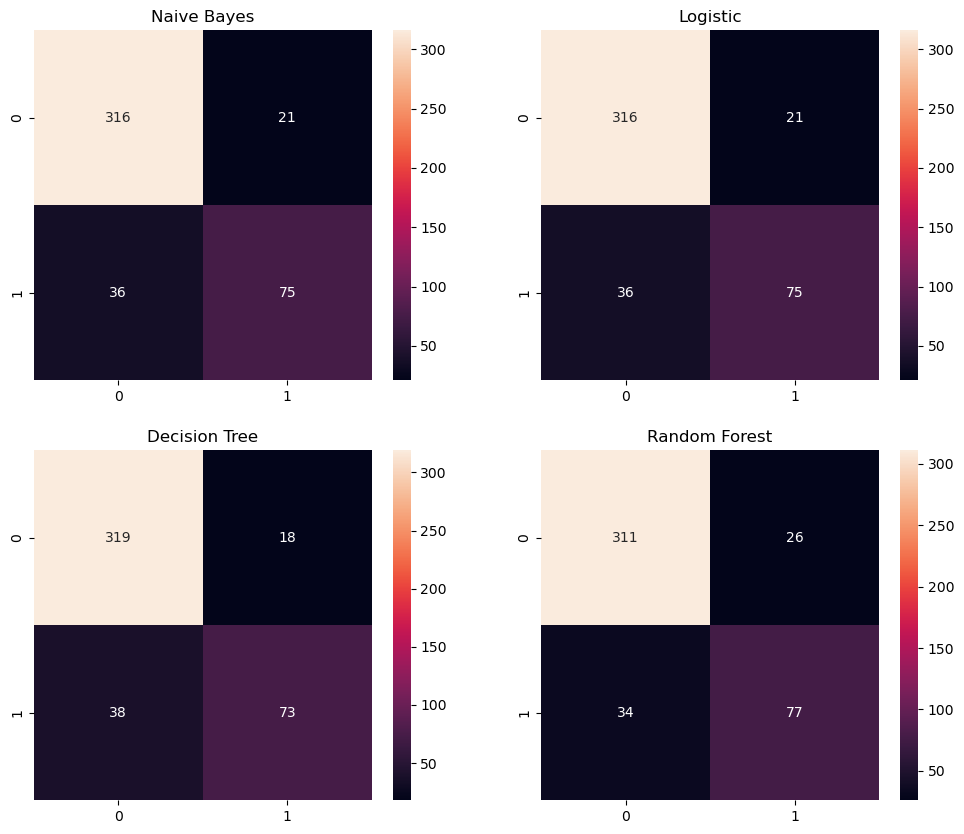

In [32]:
plt.figure(figsize=(12, 10)) # Increased height to accommodate two rows

# Row 1, Col 1
plt.subplot(2, 2, 1)
sns.heatmap(confusion_matrix(y_test, pred6), annot=True, fmt='d')
plt.title("Naive Bayes")

# Row 1, Col 2
plt.subplot(2, 2, 2)
sns.heatmap(confusion_matrix(y_test, pred6), annot=True, fmt='d')
plt.title("Logistic")

# Row 2, Col 1
plt.subplot(2, 2, 3)
sns.heatmap(confusion_matrix(y_test, pred7), annot=True, fmt='d')
plt.title("Decision Tree")

# Row 2, Col 2
plt.subplot(2, 2, 4)
sns.heatmap(confusion_matrix(y_test, pred8), annot=True, fmt='d')
plt.title("Random Forest")


plt.show()

Objective 4 — Predict Customer Income

Business Question: Can we predict customer Income from spending behavior?
Target → Income
Problem → Regression

We compare:
	•	Linear Regression
	•	Random Forest Regressor

In [33]:
X = df[['Age','Recency','Total_Spending']]
y = df['Income']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)


Model 1 - Linear Regression

In [34]:
model9 = LinearRegression()
model9.fit(X_train,y_train)

pred9 = model9.predict(X_test)
r2_1 = r2_score(y_test,pred9)
print("Linear Regression R2:",r2_1)

Linear Regression R2: 0.6851630976063223


Model 2 - Random Forest Regressor

In [35]:
model10 = RandomForestRegressor(n_estimators=100)
model10.fit(X_train,y_train)

pred11 = model10.predict(X_test)

r2_3 = r2_score(y_test,pred11)
print("Random Forest R2:",r2_3)

Random Forest R2: 0.48586862623248706


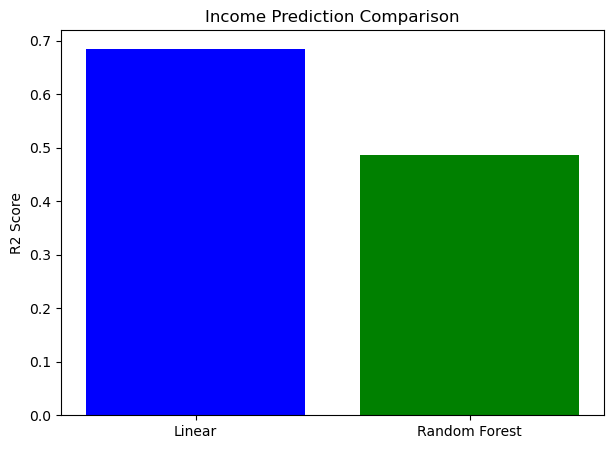

In [36]:
models = ['Linear','Random Forest']
scores = [r2_1,r2_3]

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.bar(models,scores,color=['blue','green'])

plt.title("Income Prediction Comparison")
plt.ylabel("R2 Score")

plt.show()

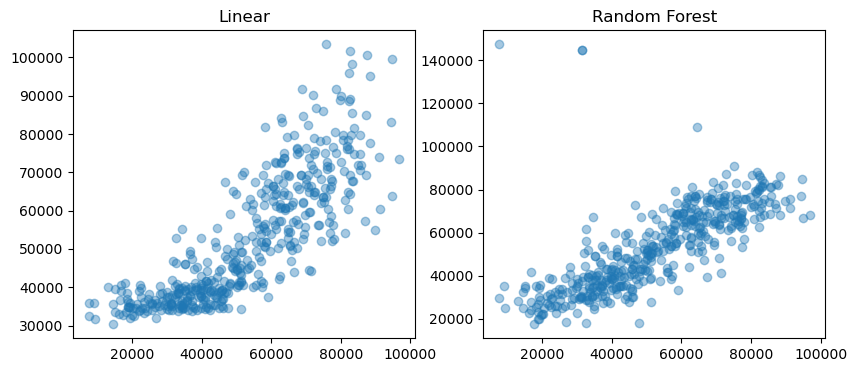

In [37]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.scatter(y_test,pred9,alpha=0.4)
plt.title("Linear")

plt.subplot(1,3,2)
plt.scatter(y_test,pred11,alpha=0.4)
plt.title("Random Forest")

plt.show()

Objective 5 — Predict Customer Education Level

Business Question: Can we predict customer Education using demographic & spending data?
Target → Education
Problem → Classification

We compare:
	•	KNN
	•	Decision Tree
	•	Random Forest

In [38]:
X = df[['Income','Age','Recency','Total_Spending']]
y = df['Education']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

Model 1 - KNN

In [39]:
model12 = KNeighborsClassifier(n_neighbors=5)
model12.fit(X_train,y_train)

pred12 = model12.predict(X_test)
acc12 = accuracy_score(y_test,pred12)
print("KNN Accuracy:",acc12)

KNN Accuracy: 0.4375


Model 2 - Decision Tree

In [40]:
model13 = DecisionTreeClassifier(max_depth=4)
model13.fit(X_train,y_train)

pred13 = model13.predict(X_test)

acc13 = accuracy_score(y_test,pred13)
print("Decision Tree Accuracy:",acc13)

Decision Tree Accuracy: 0.5089285714285714


Model 3 - Random Forest

In [41]:

model14 = RandomForestClassifier(n_estimators=100)
model14.fit(X_train,y_train)

pred14 = model14.predict(X_test)

acc14 = accuracy_score(y_test,pred14)
print("Random Forest Accuracy:",acc14)

Random Forest Accuracy: 0.546875


COMPARE

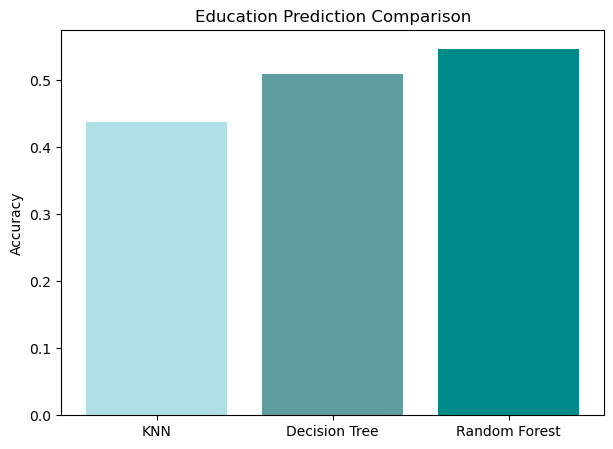

In [42]:
models = ['KNN','Decision Tree','Random Forest']
scores = [acc12,acc13,acc14]

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.bar(models,scores,color=['powderblue', 'cadetblue', 'darkcyan'])

plt.title("Education Prediction Comparison")
plt.ylabel("Accuracy")

plt.show()

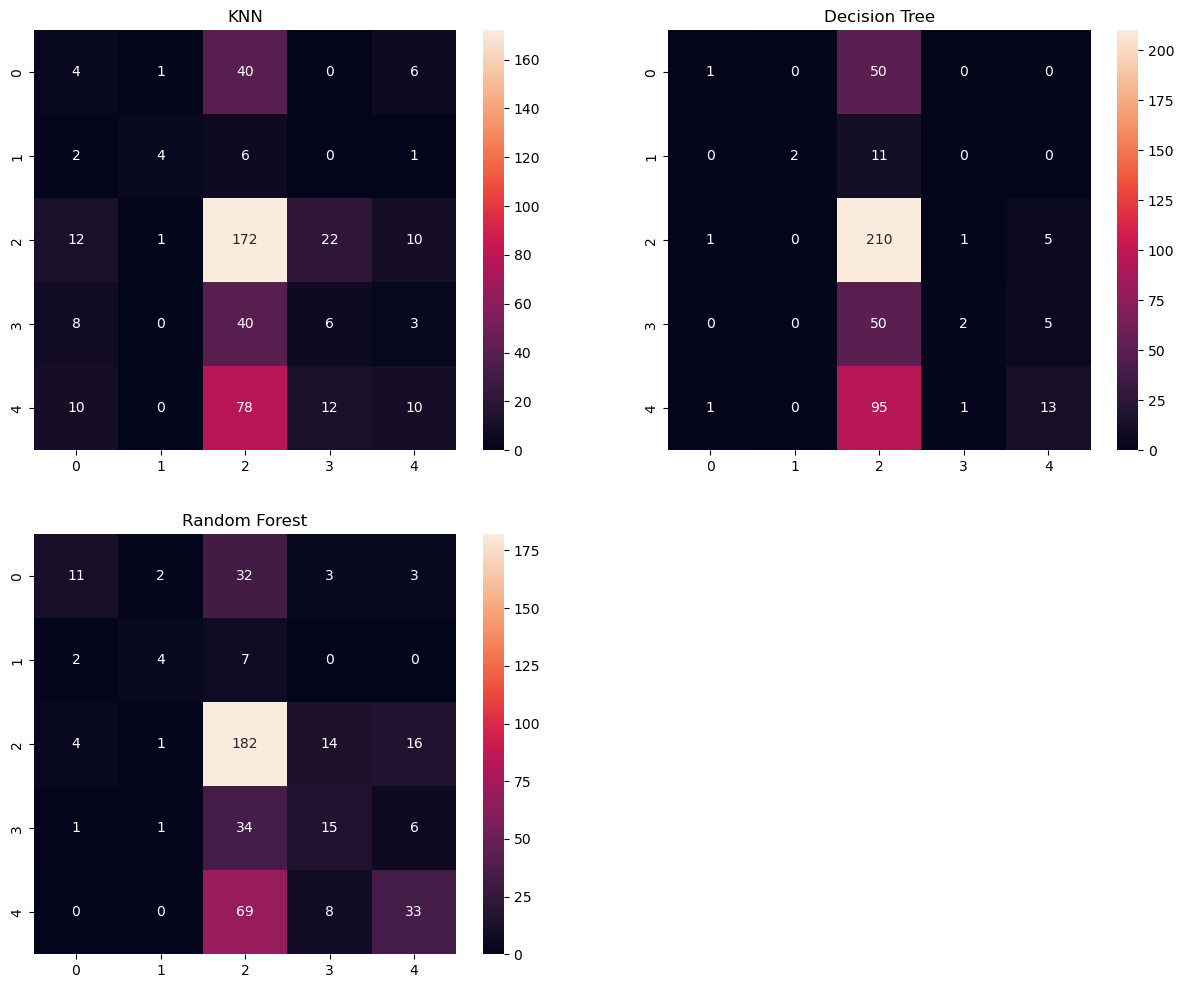

In [46]:
plt.figure(figsize=(15,12))

plt.subplot(2,2,1)
sns.heatmap(confusion_matrix(y_test,pred12),annot=True,fmt='d')
plt.title("KNN")

plt.subplot(2,2,2)
sns.heatmap(confusion_matrix(y_test,pred13),annot=True,fmt='d')
plt.title("Decision Tree")

plt.subplot(2,2,3)
sns.heatmap(confusion_matrix(y_test,pred14),annot=True,fmt='d')
plt.title("Random Forest")

plt.show()